# Tarea 04 — Visualización de Datos con Matplotlib

**Instrucciones:** Completa cada celda de código con tu respuesta.  
Usarás la interfaz orientada a objetos de Matplotlib (`fig, ax = plt.subplots()`).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Dataset de trabajo
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

---
## Parte 1 — Figura y ejes

**P1.** Crea una figura con `plt.subplots()` de tamaño 8×5.  
Haz un gráfico de línea con los primeros 20 valores de `sepal_length`.  
Agrega título `"Longitud del sépalo"` y etiquetas en ambos ejes.

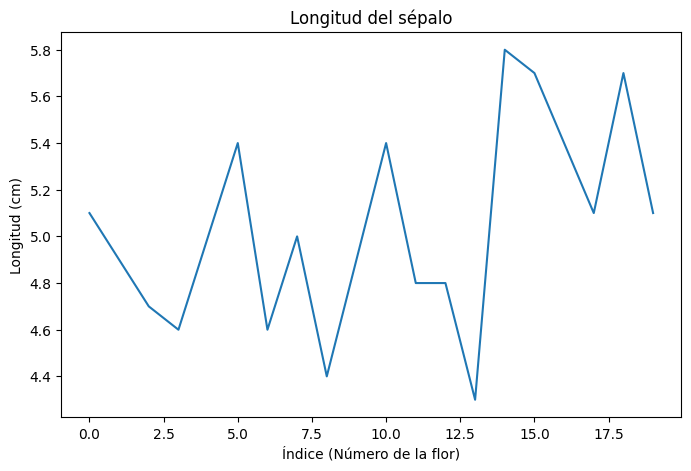

In [2]:
import matplotlib.pyplot as plt

primeros_20 = df['sepal_length'].head(20)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(primeros_20)
ax.set_title("Longitud del sépalo")
ax.set_xlabel("Índice (Número de la flor)")
ax.set_ylabel("Longitud (cm)")
plt.show()


---
## Parte 2 — Gráfico de barras

**P2.** Calcula el promedio de `petal_length` por especie (`species`) y guárdalo en una variable.  
Luego crea un **gráfico de barras vertical** con esos promedios.  
Agrega título y etiquetas en ambos ejes.

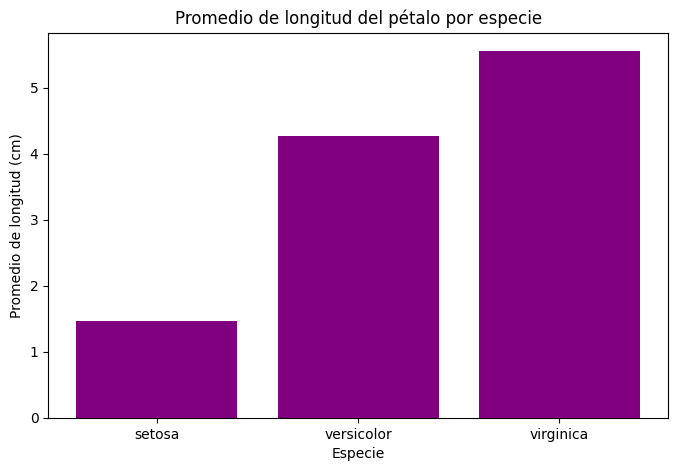

In [4]:
promedios_petalo = df.groupby('species')['petal_length'].mean()

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(promedios_petalo.index, promedios_petalo.values, color="purple")
ax.set_title("Promedio de longitud del pétalo por especie")
ax.set_xlabel("Especie")
ax.set_ylabel("Promedio de longitud (cm)")

plt.show()


---
## Parte 3 — Dispersión (scatter plot)

**P3.** Crea un **gráfico de dispersión** (scatter) con `sepal_length` en el eje X y `sepal_width` en el eje Y.  
Usa un color diferente para cada especie (puedes filtrar el DataFrame tres veces o usar un bucle).  
Agrega leyenda, título y etiquetas.

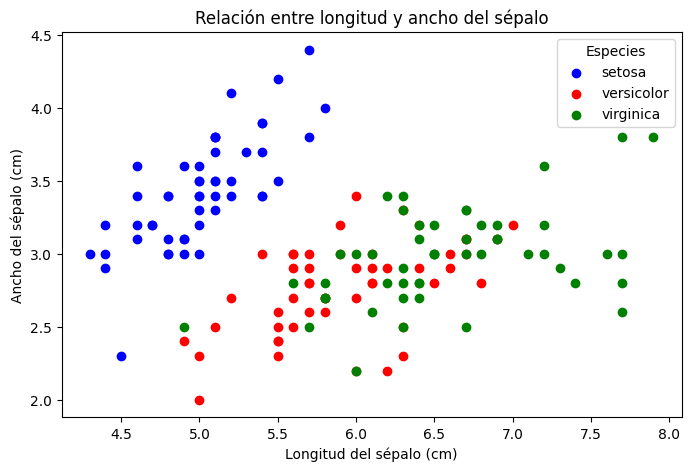

In [13]:
especies = df["species"].unique()
colores = ["blue", "red", "green"]

fig, ax = plt.subplots(figsize=(8, 5))

# Tu respuesta aquí: itera sobre especies y colores para graficar cada grupo
for especie, color in zip(especies, colores):
    
    datos_especie = df[df["species"] == especie]
    ax.scatter(datos_especie["sepal_length"], 
               datos_especie["sepal_width"], 
               color=color, 
               label=especie)

ax.set_title("Relación entre longitud y ancho del sépalo")
ax.set_xlabel("Longitud del sépalo (cm)")
ax.set_ylabel("Ancho del sépalo (cm)")

ax.legend(title="Especies")

plt.show()


---
## Parte 4 — Histograma

**P4.** Crea un **histograma** de la columna `petal_width` con 15 bins.  
Agrega una línea vertical punteada en el valor de la media con `ax.axvline()`.  
Agrega título y etiquetas.

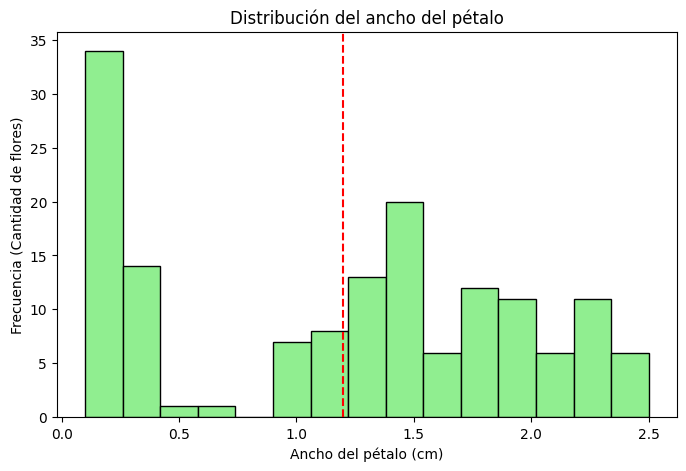

In [8]:
media_ancho_petalo = df['petal_width'].mean()

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(df['petal_width'], bins=15, color='lightgreen', edgecolor='black')

ax.axvline(x=media_ancho_petalo, color='red', linestyle='--')

ax.set_title("Distribución del ancho del pétalo")
ax.set_xlabel("Ancho del pétalo (cm)")
ax.set_ylabel("Frecuencia (Cantidad de flores)")


plt.show()


---
## Parte 5 — Guardar figura

**P5.** Recrea el gráfico de barras de P2 y guárdalo como imagen PNG en `output/promedios_iris.png`.  
Usa `dpi=100` y `bbox_inches="tight"`.

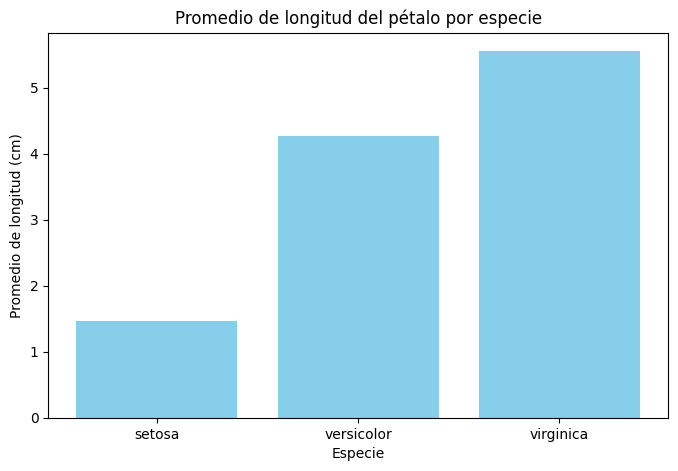

In [14]:
import os
os.makedirs("output", exist_ok=True)

promedios_petalo = df.groupby('species')['petal_length'].mean()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(promedios_petalo.index, promedios_petalo.values, color='skyblue')

ax.set_title("Promedio de longitud del pétalo por especie")
ax.set_xlabel("Especie")
ax.set_ylabel("Promedio de longitud (cm)")

fig.savefig("output/promedios_iris.png", dpi=100, bbox_inches="tight")

plt.show()
